In [5]:
import re
import os
import pytesseract
from PIL import Image
from rapidfuzz import fuzz
import matplotlib.pyplot as plt

In [6]:
# List of available languages
print(pytesseract.get_languages(config=""))

['eng', 'osd', 'tha']


## Prototype


In [7]:
prefix = "."
folder_path = os.path.join(prefix, "images", "course")

# Extract image files
image_file_paths = []
for file in os.listdir(folder_path):
    file_lower = file.lower()
    if (
        file_lower.endswith(".jpg")
        or file_lower.endswith(".png")
        or file_lower.endswith(".jpeg")
    ):
        image_file_paths.append(os.path.join(folder_path, file))
print("Image files found:", image_file_paths)

Image files found: ['.\\images\\course\\0e4fb100-0d2a-438a-88fa-26d2ea6eef6a_NATTANICHA TIPNET.jpg', '.\\images\\course\\1_SURADIT SUKSAP.png', '.\\images\\course\\650610367-ประเมินการสอน_CHANUNRAT NOK-IN.PNG', '.\\images\\course\\650610404 ประเมินวิชา_THANRADA YEUNSUK.JPG', '.\\images\\course\\Capture_NATTANICHA TIBPALA.PNG', '.\\images\\course\\Capture_PARAMA WILAIWAN.PNG', '.\\images\\course\\gg_TANUSORN AINTARAPU.JPG', '.\\images\\course\\messageImage_1762226361204_THAWANRAT SAENASUTTI.jpg', '.\\images\\course\\Screenshot (1)_SURACHET WICHA.png', '.\\images\\course\\Screenshot (11)_CHUTINAN SUMPAWO.png', '.\\images\\course\\Screenshot 2025-11-03 133348_TAYAGORN PRATHUMPITA.png', '.\\images\\course\\Screenshot 2025-11-03 133756_NICHA MALIWAN.png', '.\\images\\course\\Screenshot 2025-11-03 134629_JETSADA PHAISON.png', '.\\images\\course\\Screenshot 2025-11-03 135126_KALANYUTA WORAPHATWI.png', '.\\images\\course\\subject_KULAWATTANA KHIAOTIP.PNG', '.\\images\\course\\ประเมินการสอน_BUN

Processed OCR Output:
9 6บเ๒อ์ท % | / ศิกสไยต๓ /% | (ว ทิกสเพอยอ๓: % | พี้ซี ศิกย1255441- % | @ พะอท และไิ(0 % โป 0อนรอกรรรร % 680-201อ๒๓๓ % | ดจ 6๐201๐๒๓ % | + - % « > ๕ เร.ฮเทน.ธ6ฝ่า/๕๓ทนรไธ/๒ิหล!นลน์อทโลลตา/๐อนเธอ/ใรรอรร?ตลยุอ=ือนกรอภเธรอรร * ๆ @ 8ชี | @ ๐หบเ๒ชูท /วั ๒ แขแพญี ส าค][ฒ6 @ ทะเบียนประวัต ' ซ ประเมินการเรียนการสอน [ธี] ข่าวกิจกรรม [27 ประเมินการสง จุ .@ ประเมินกระบวนวิชา ซิ ประเมิ เระเมินการสอน ส ระบบจัดหางาน ึ่ วิชาที่ “ รายชือกระบวนวิชาที่ลงทะเบียนสอน โป๊ฐฬ ระบบทุนการศึกษา “” พบรายการทั้งสิ้น 5 รายการ จ@ เฉแบเททย์ รหัสกระบวนวิชา ชื่อกระบวนวิชา 'ตอนบรรยาย ประเภทกระบวนวิชา สถานะการประเมิน โก " 255439 ว๑ต์รเอท หเธได่ทธ โอก อิทธิไทอ๑กร 001 000 บรรยาย (เอ๕น76) 8 ยังไม่ได้ประเมิน =@ 1ธ โอ/ อทธิ กิจครรมสาธารณประโยชน์ 255441 แกร็อกทลย่อท โลยททอ|อด โอ/ เกล่บรมท่อ| อิทธูใกอ๑5 001 000 บรรยาย (เ@๐๑) ” ประเมินแล้ว 'ญ ระบบกิจกรรมนักศึกษา “” 255447 เทผ่นระท่ด| พิอ๒อย่๐ รกส์ /เทหเกิตเธ| !ทแอ[ไธ๑ก๐๑ /เวอไซรย์อกร 001 000 บรรยาย (เอ๕น76) 8 ยังไม่ได้ประเมิน [ซิธท๕๑ /เอต| @ ปธิการสําหรับนั

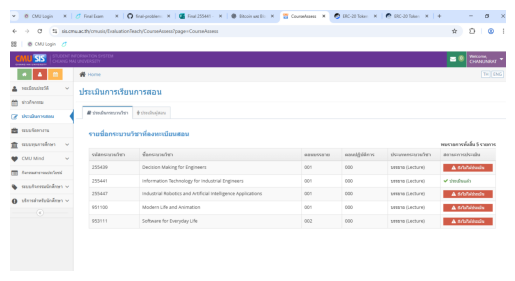

In [8]:
filepath = image_file_paths[2]  # Use the first image file for processing

language = "tha"
matching_texts = [
    "255441",
    "ประเมินแล้ว",
]
weights = [0.5, 0.5]

# language = "eng"
# matching_texts = [
#     "255441",
#     "Nirand",
#     "Pisutha-Arnond",
# ]

_text = pytesseract.image_to_string(Image.open(filepath), lang=language).strip()
# print("Raw OCR Output:")
# print(_text)
# Remove multiple whitespaces
text = re.sub(r"\s+", " ", _text)
# Remove line breaks
text = re.sub(r"\n+", " ", text)
print("Processed OCR Output:")
print(text)

# process.extract("นิรันดร์ พิสุทธอานนท์", [text_th], scorer=fuzz.partial_ratio)
score_arr = []
for matching_text in matching_texts:
    score = fuzz.partial_ratio(matching_text, text)
    score_arr.append(score)
    print(f"Matching '{matching_text}' with OCR output: {score}%")

weighted_score = sum(score * weight for score, weight in zip(score_arr, weights))
print(f"Weighted Score: {weighted_score}%")

plt.imshow(Image.open(filepath))
plt.axis("off")
plt.show()

In [9]:
def evaluate_ocr(filepath, language, matching_texts, weights):
    _text = pytesseract.image_to_string(Image.open(filepath), lang=language).strip()
    text = re.sub(r"\s+", " ", _text)
    text = re.sub(r"\n+", " ", text)

    scores = []
    for matching_text in matching_texts:
        score = fuzz.partial_ratio(matching_text, text)
        scores.append(dict(matching_text=matching_text, score=score))
    weighted_score = sum(
        score["score"] * weight for score, weight in zip(scores, weights)
    )
    return dict(
        scores=scores,
        weighted_score=weighted_score,
        ocr_text=text,
        filepath=filepath,
        language=language,
    )

In [11]:
result_arr = []
for image_file_path in image_file_paths:
    result = evaluate_ocr(image_file_path, language, matching_texts, weights)
    result_arr.append(result)
    for score_info in result["scores"]:
        print(
            f"  Matching '{score_info['matching_text']}': {score_info['score']}%",
        )
    print(f"  Weighted Score: {result['weighted_score']}%")
    print(f"  OCR Text: {result['ocr_text']}\n")

  Matching '255441': 100.0%
  Matching 'ประเมินแล้ว': 100.0%
  Weighted Score: 100.0%
  OCR Text: ไ[ไลทลธ6ทาลอทะ 255441 เทโอกทาลนพีอท 001 000 บรรยาย จ ประเมินแล้ว ไล6ททอ๐!อ0ธง (('ด6โนหอล) โอห เทส่นรแทล! ธิทยเทลอทร

  Matching '255441': 100.0%
  Matching 'ประเมินแล้ว': 100.0%
  Weighted Score: 100.0%
  OCR Text: .@ ประเมินกระบวนวิชา ซ) ประเมินผู้สอน รายชื่อกระบวนวิชาที่ลงทะเบียนสอน 'พบรายการทั้งสิ้น 5 รายการ รหัสกระบวนวิชา ชื่อกระบวนวิชา. ตอนบรรยาย ตอนปฏิบัติการ .ประเภทกระบวนวิชา สถานะการประเมิน 255320 : 7+' 002 000 บรรยาย (@๕น69) 255321 แทต่นระท่ธ| อิทธิเทร6ท์ทธ ฉุนรไซ 6อททอ! 002 .000 บรรยาย (1๕บ6) 255441 แหร็อททรขอก โออําทอ|อธู โอท !กล่นระทได| อิทธิไทร๑กร 001 000 บรรยาย (.๑๐๑) ” ประเมินแล้ว 255447 แทต่นระท่ธ| สอ๒อย์6 ลทส์ คก์กิต| เทชด|ไธธท๕6 /เออ!ไซสมีอทร 001 .000 บรรยาย (1๑๕บ6) 255490 เช่นลทย๑ส โอดโฮร ไท !ทลั่นระทีส| 6ทธิ!ทรอทกฐู 1 001 000 บรรยาย (!@๕น6๑) ฏ ถังไม่ได้ประเมิน

  Matching '255441': 100.0%
  Matching 'ประเมินแล้ว': 100.0%
  Weighted Score: 100.0%
  OCR Text: 9 6บเ๒อ์ท % 

Low OCR quality for .\images\course\ประเมินวิชา_NINNAT KLAROB.PNG (Weighted Score: 31.66666666666667%)
  OCR Text: ชินนทท ๓ลังจ 6560610น816 ๐ วริหา



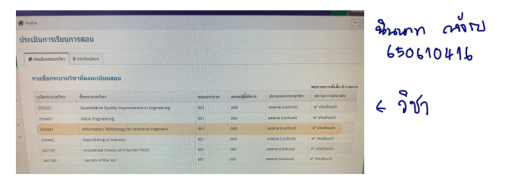

Low OCR quality for .\images\course\วิชา_JIRAWAN GANTEEMOL.png (Weighted Score: 66.66666666666667%)
  OCR Text: เณ 2 8082 ๑ ๑ กกิ 4« เซ ๑ ทะเบียนประวัติ ข่าวกิจกรรม " . ประเมินกระบวนวิชา ซู ประเมินผู้สอน รระบบจัดหางาน ระบบทุนการศึกษา 3” รหัสกระบวนวิชา ระบบกิจกรรมนักศึกษา “” บริการสําหรับนักศึกษา “” ร ประเมินการเรียนการสอน เร.ฮเทน.ธ6ฝ่า/๕๓ทนรไธ/๒ิหล!นลน์อทโลลตา/๐อนเธอ/ใรรอรร?ตลยุอ=ือนกรอภเธรอรร รายชื่อกระบวนวิชาที่ลงทะเบียนสอน ชือกระบวนวิชา 4หผีกิตร| เกแชไซ๑ทะ๑ ฮกส่ ปิเธแล| ธรรอกบ้อไร (6๑|๓นในรโอท ซิทธิโทลอท์ทธู 3 5เกทน|ธย์อท ร์อก คิหอลั่นตอท ลทซ์ 1.อธูไรีร 5ปรแอกา แหล่บรยทล| ห่มธเสทร แคร์อทททรน์อก โลยททอเอธห โอห ทล่นรมท่อ| 6ิทธิใทรลกร แกตั่นระท่อ| อิทธูไทรอทัทธุ ปิหออ๓ 1หลต16ลน์อกร ไท ซิหอท/ส่อ นก์อ ตอนบรรยาย 002 003 001 001 001 000 001 (6๐๓ห ศิเซทะ อ 2025 - 6ทเธกทธ ใหล| ปทโพอทรโญ /ป| ท่ชูทะ หตรอทเลค่. ตอนปฏิบัติการ 000 000 000 000 000 018 000 ประเภทกระบวนวิชา บรรยาย (เอ๕๒7@) บรรยาย (เอ๕น76) บรรยาย (เอ๕๒7@) บบรรยาย (1 @๕๓6) บรรยาย (เอ๕๒7@) ปฏิบัติการ (130) บรรยาย (เ๑๕น66) ภเผล าห][ฮ6 '

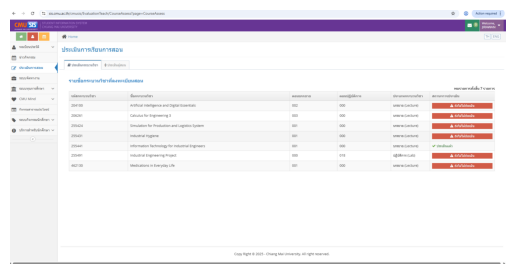

In [ ]:
for result in result_arr:
    if result["weighted_score"] < 75:
        print(
            f"Low OCR quality for {result['filepath']} (Weighted Score: {result['weighted_score']}%)"
        )
        print(f"  OCR Text: {result['ocr_text']}\n")
        plt.imshow(Image.open(result["filepath"]))
        plt.axis("off")
        plt.show()